imports and paths


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path("..")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

CENTROID_PATH = PROCESSED_DIR / "04_centroid_drift"
GAUSSIAN_PATH = PROCESSED_DIR / "06_gaussian_distribution_drift"
COMPARISON_PATH = PROCESSED_DIR / "07_centroid_gaussian_comparison"

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures" / "RQ1"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = PROJECT_ROOT / "outputs" / "tables" / "RQ1"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

centroid = pd.read_parquet(
    CENTROID_PATH / "centroid_drift_wpz_neighbors.parquet"
)

gaussian = pd.read_parquet(
    GAUSSIAN_PATH / "gaussian_w2_drift_wpz_neighbors.parquet"
)

centroid.head()


,modality,genre,window_start,window_end,next_window_start,next_window_end,window_gap,n_tracks_t,n_tracks_t1,cosine_similarity,cosine_distance
0,essentia,alternative metal,1995,1999,1996,2000,1,21,22,0.958763,0.041237
1,essentia,alternative metal,1996,2000,1997,2001,1,22,34,0.948263,0.051737
2,essentia,alternative metal,1997,2001,1998,2002,1,34,51,0.960931,0.039069
3,essentia,alternative metal,1998,2002,1999,2003,1,51,44,0.985195,0.014805
4,essentia,alternative metal,1999,2003,2000,2004,1,44,39,0.995410,0.004590


basic checks


In [2]:
print(centroid.shape)
print(gaussian.shape)

print(centroid["modality"].value_counts())
print(gaussian["modality"].value_counts())

print(centroid["window_gap"].value_counts().sort_index())
print(gaussian["window_gap"].value_counts().sort_index())


(18268, 11)
(14913, 13)
modality
essentia         3076
lyrics_tf_idf    3076
word2vec         3076
mfcc             3076
musicnn          3076
vgg19            2888
Name: count, dtype: int64
modality
essentia         2515
lyrics_tf_idf    2515
word2vec         2515
mfcc             2515
musicnn          2515
vgg19            2338
Name: count, dtype: int64
window_gap
1    18268
Name: count, dtype: int64
window_gap
1    14913
Name: count, dtype: int64


# merge centroid and distribution-based drift


In [3]:
merge_columns = [
    "modality",
    "genre",
    "window_start",
    "next_window_start"
]

dataset_combined = centroid.merge(
    gaussian,
    on=merge_columns,
    how="inner",
    validate="one_to_one",
    suffixes=("_centroid", "_gaussian")
)

dataset_combined.to_parquet(
    COMPARISON_PATH / "centroid_gaussian_drift_comparison.parquet",
    index=False
)

print(dataset_combined.shape)
dataset_combined.head()


(14913, 20)


,modality,genre,window_start,window_end_centroid,next_window_start,next_window_end_centroid,window_gap_centroid,n_tracks_t_centroid,n_tracks_t1_centroid,cosine_similarity,cosine_distance,window_end_gaussian,next_window_end_gaussian,window_gap_gaussian,n_tracks_t_gaussian,n_tracks_t1_gaussian,w2_distance,w2_squared,mean_component,std_component
0,essentia,alternative metal,1997,2001,1998,2002,1,34,51,0.960931,0.039069,2001,2002,1,34,51,13.582441,184.482690,3.446403,13.137922
1,essentia,alternative metal,1998,2002,1999,2003,1,51,44,0.985195,0.014805,2002,2003,1,51,44,6.074669,36.901601,2.795829,5.393045
2,essentia,alternative metal,1999,2003,2000,2004,1,44,39,0.995410,0.004590,2003,2004,1,44,39,2.794587,7.809717,1.699129,2.218711
3,essentia,alternative metal,2000,2004,2001,2005,1,39,59,0.965764,0.034236,2004,2005,1,39,59,7.128377,50.813760,4.045676,5.869094
4,essentia,alternative metal,2001,2005,2002,2006,1,59,56,0.982122,0.017878,2005,2006,1,59,56,6.359724,40.446092,2.492853,5.850793


# merge validation


In [4]:
validation_summary = pd.DataFrame({
    "measure": [
        "centroid_rows",
        "gaussian_rows",
        "merged_rows",
        "duplicate_merged_rows",
        "missing_cosine_distance",
        "missing_w2_distance",
        "missing_mean_component",
        "missing_std_component"
    ],
    "value": [
        len(centroid),
        len(gaussian),
        len(dataset_combined),
        dataset_combined.duplicated(merge_columns).sum(),
        dataset_combined["cosine_distance"].isna().sum(),
        dataset_combined["w2_distance"].isna().sum(),
        dataset_combined["mean_component"].isna().sum(),
        dataset_combined["std_component"].isna().sum()
    ]
})

validation_summary.to_csv(
    TABLE_DIR / "rq1_centroid_gaussian_merge_validation.csv",
    index=False
)

validation_summary


,measure,value
0,centroid_rows,18268
1,gaussian_rows,14913
2,merged_rows,14913
3,duplicate_merged_rows,0
4,missing_cosine_distance,0
5,missing_w2_distance,0
6,missing_mean_component,0
7,missing_std_component,0


# modality-level drift summary


In [5]:
modality_summary = (
    dataset_combined
    .groupby("modality")
    .agg(
        n_valid_transitions=("cosine_distance", "count"),
        mean_cosine_drift=("cosine_distance", "mean"),
        median_cosine_drift=("cosine_distance", "median"),
        std_cosine_drift=("cosine_distance", "std"),
        mean_w2_drift=("w2_distance", "mean"),
        median_w2_drift=("w2_distance", "median"),
        std_w2_drift=("w2_distance", "std"),
        mean_mean_component=("mean_component", "mean"),
        median_mean_component=("mean_component", "median"),
        mean_std_component=("std_component", "mean"),
        median_std_component=("std_component", "median")
    )
    .sort_values("median_cosine_drift", ascending=False)
    .reset_index()
)

modality_summary.to_csv(
    COMPARISON_PATH / "modality_drift_summary.csv",
    index=False
)

modality_summary.to_csv(
    TABLE_DIR / "rq1_centroid_gaussian_modality_summary.csv",
    index=False
)

modality_summary


,modality,n_valid_transitions,mean_cosine_drift,median_cosine_drift,std_cosine_drift,mean_w2_drift,median_w2_drift,std_w2_drift,mean_mean_component,median_mean_component,mean_std_component,median_std_component
0,lyrics_tf_idf,2515,0.124429,0.114599,0.075069,11.962482,11.829493,4.202436,2.095477,2.015680,11.769251,11.663931
1,vgg19,2338,0.090841,0.068966,0.081544,12.444504,11.502626,6.170147,7.515537,6.771687,9.845242,9.159245
2,word2vec,2515,0.049568,0.029157,0.062235,1.569341,1.421017,0.828246,1.201137,1.097865,0.985943,0.872289
3,essentia,2515,0.042223,0.025174,0.054713,6.084773,4.942005,5.213534,2.243250,2.015251,5.568252,4.412625
4,mfcc,2515,0.041427,0.023209,0.054169,1.399564,1.106506,1.107577,0.700248,0.612343,1.179446,0.877180
5,musicnn,2515,0.015934,0.006828,0.027836,0.989933,0.796258,0.733379,0.481418,0.402974,0.840693,0.644154


- **Lyrics TF-IDF:** highest centroid drift; W2 mainly from spread
- **VGG19:** very high W2; strong mean and spread changes
- **Word2Vec:** moderate centroid drift; low W2
- **Essentia:** moderate centroid drift; high spread-related W2
- **MFCC:** low drift in both measures
- **MusicNN:** most stable modality
- **Mean > median:** some strong outliers
- **Caution:** raw W2 not directly comparable across dimensions

In [6]:
ranking_comparison = modality_summary[
    [
        "modality",
        "median_cosine_drift",
        "median_w2_drift"
    ]
].copy()

ranking_comparison["centroid_rank"] = (
    ranking_comparison["median_cosine_drift"]
    .rank(ascending=False, method="min")
)

ranking_comparison["gaussian_rank"] = (
    ranking_comparison["median_w2_drift"]
    .rank(ascending=False, method="min")
)

ranking_comparison["rank_difference"] = (
    ranking_comparison["gaussian_rank"]
    - ranking_comparison["centroid_rank"]
)

ranking_comparison = ranking_comparison.sort_values("centroid_rank")

ranking_comparison.to_csv(
    TABLE_DIR / "rq1_centroid_gaussian_modality_ranking.csv",
    index=False
)

ranking_comparison


,modality,median_cosine_drift,median_w2_drift,centroid_rank,gaussian_rank,rank_difference
0,lyrics_tf_idf,0.114599,11.829493,1.0,1.0,0.0
1,vgg19,0.068966,11.502626,2.0,2.0,0.0
2,word2vec,0.029157,1.421017,3.0,4.0,1.0
3,essentia,0.025174,4.942005,4.0,3.0,-1.0
4,mfcc,0.023209,1.106506,5.0,5.0,0.0
5,musicnn,0.006828,0.796258,6.0,6.0,0.0


# correlation between centroid and distribution-based drift


In [7]:
correlation_rows = []

for modality, modality_data in dataset_combined.groupby("modality"):
    correlation_rows.append({
        "modality": modality,
        "n_valid_transitions": len(modality_data),
        "spearman_cosine_w2": modality_data[
            "cosine_distance"
        ].corr(
            modality_data["w2_distance"],
            method="spearman"
        ),
        "pearson_cosine_w2": modality_data[
            "cosine_distance"
        ].corr(
            modality_data["w2_distance"],
            method="pearson"
        ),
        "spearman_cosine_mean_component": modality_data[
            "cosine_distance"
        ].corr(
            modality_data["mean_component"],
            method="spearman"
        ),
        "pearson_cosine_mean_component": modality_data[
            "cosine_distance"
        ].corr(
            modality_data["mean_component"],
            method="pearson"
        ),
        "spearman_cosine_std_component": modality_data[
            "cosine_distance"
        ].corr(
            modality_data["std_component"],
            method="spearman"
        ),
        "pearson_cosine_std_component": modality_data[
            "cosine_distance"
        ].corr(
            modality_data["std_component"],
            method="pearson"
        )
    })

correlation_summary = (
    pd.DataFrame(correlation_rows)
    .sort_values("spearman_cosine_w2", ascending=False)
)

correlation_summary.to_csv(
    TABLE_DIR / "rq1_centroid_gaussian_correlations.csv",
    index=False
)

correlation_summary


,modality,n_valid_transitions,spearman_cosine_w2,pearson_cosine_w2,spearman_cosine_mean_component,pearson_cosine_mean_component,spearman_cosine_std_component,pearson_cosine_std_component
1,lyrics_tf_idf,2515,0.794915,0.807994,0.619083,0.653633,0.799969,0.811816
2,mfcc,2515,0.675308,0.611135,0.717314,0.642211,0.626457,0.573873
4,vgg19,2338,0.654594,0.669165,0.666711,0.696434,0.628692,0.622408
3,musicnn,2515,0.622089,0.400257,0.708503,0.489538,0.557980,0.350559
5,word2vec,2515,0.618215,0.577397,0.648137,0.607849,0.571407,0.485567
0,essentia,2515,0.518921,0.551457,0.615860,0.657701,0.473397,0.525219


- **Lyrics TF-IDF:** strongest agreement; centroid drift closely matches W2 and spread changes
- **MFCC:** strong agreement; centroid drift especially related to mean movement
- **VGG19:** strong and balanced agreement with mean and spread changes
- **MusicNN:** similar ranking, but weaker linear relationship
- **Word2Vec:** moderate agreement; mainly connected to mean movement
- **Essentia:** weakest agreement; Gaussian drift adds the most additional information
- **Overall:** centroid and Gaussian drift are positively related in every modality

# centroid drift by modality


<Figure size 1000x500 with 0 Axes>

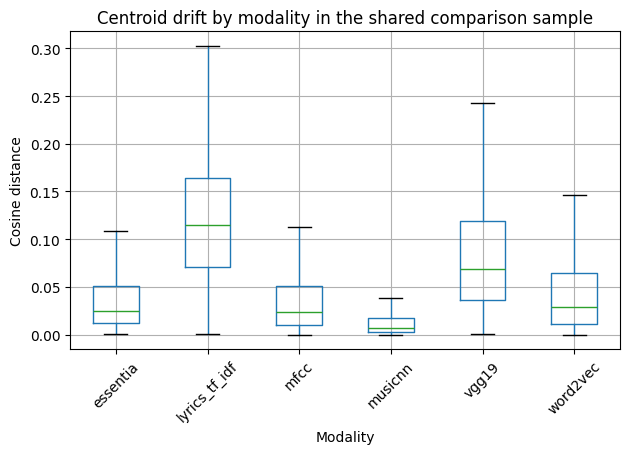

In [8]:
plt.figure(figsize=(10, 5))

dataset_combined.boxplot(
    column="cosine_distance",
    by="modality",
    rot=45,
    showfliers=False
)

plt.title("Centroid drift by modality in the shared comparison sample")
plt.suptitle("")
plt.xlabel("Modality")
plt.ylabel("Cosine distance")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rq1_comparison_centroid_drift_by_modality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "rq1_comparison_centroid_drift_by_modality.pdf",
    bbox_inches="tight"
)

plt.show()


# Gaussian distribution drift by modality


<Figure size 1000x500 with 0 Axes>

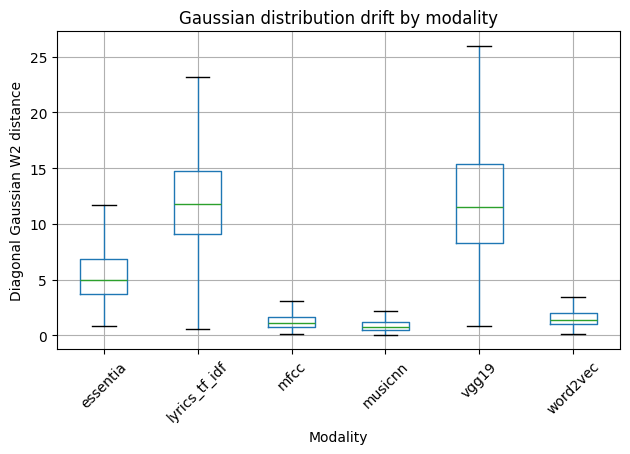

In [9]:
plt.figure(figsize=(10, 5))

dataset_combined.boxplot(
    column="w2_distance",
    by="modality",
    rot=45,
    showfliers=False
)

plt.title("Gaussian distribution drift by modality")
plt.suptitle("")
plt.xlabel("Modality")
plt.ylabel("Diagonal Gaussian W2 distance")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rq1_comparison_gaussian_w2_drift_by_modality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "rq1_comparison_gaussian_w2_drift_by_modality.pdf",
    bbox_inches="tight"
)

plt.show()


# centroid and Gaussian drift relationship


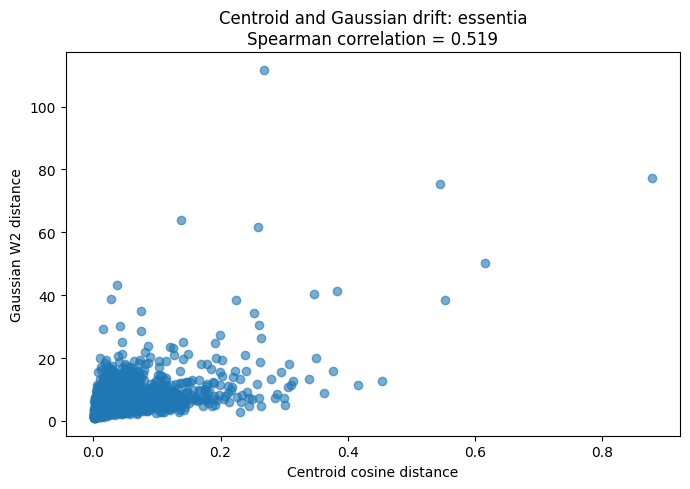

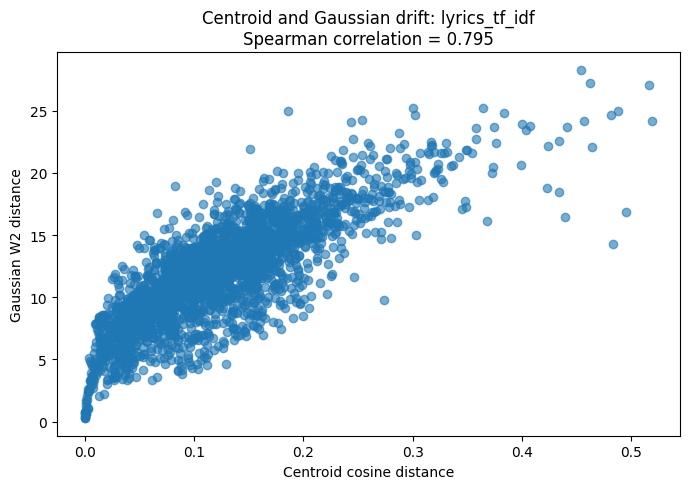

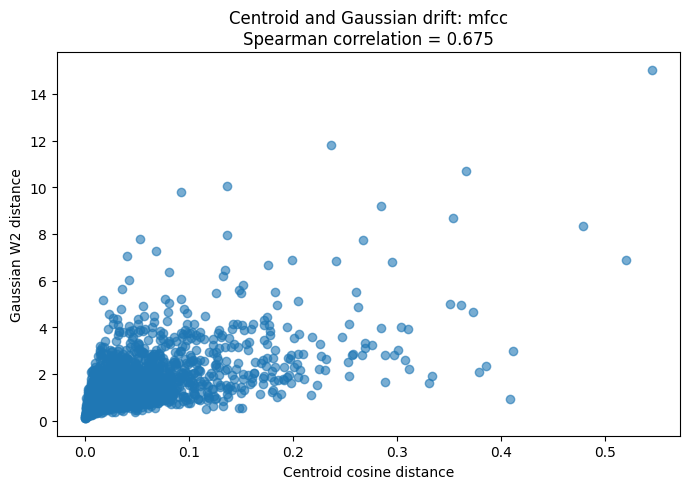

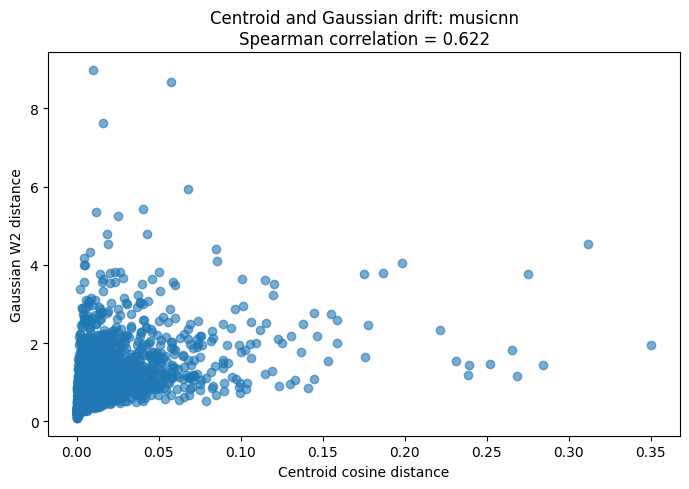

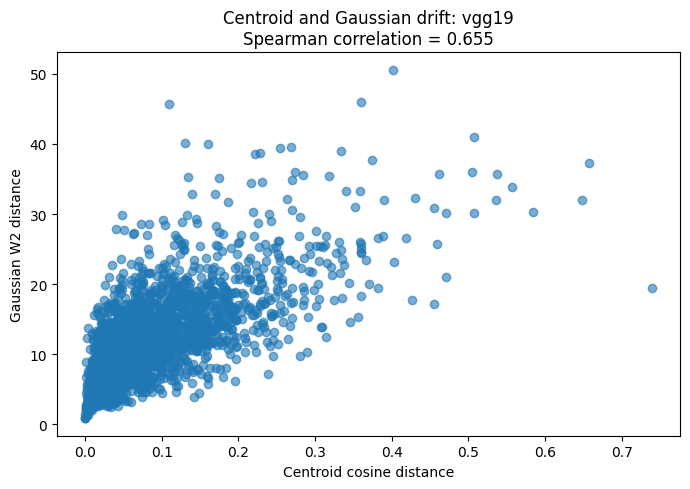

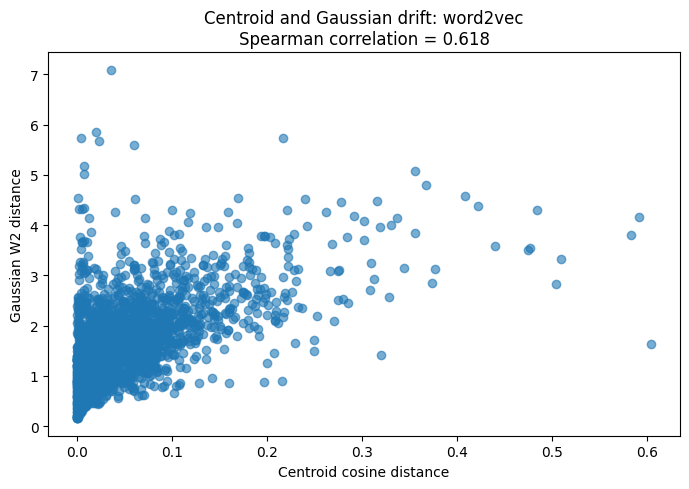

In [10]:
for modality, modality_data in dataset_combined.groupby("modality"):
    spearman_correlation = modality_data[
        "cosine_distance"
    ].corr(
        modality_data["w2_distance"],
        method="spearman"
    )

    plt.figure(figsize=(7, 5))

    plt.scatter(
        modality_data["cosine_distance"],
        modality_data["w2_distance"],
        alpha=0.6
    )

    plt.xlabel("Centroid cosine distance")
    plt.ylabel("Gaussian W2 distance")
    plt.title(
        f"Centroid and Gaussian drift: {modality}\n"
        f"Spearman correlation = {spearman_correlation:.3f}"
    )
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / f"rq1_centroid_vs_gaussian_drift_{modality}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        FIGURE_DIR / f"rq1_centroid_vs_gaussian_drift_{modality}.pdf",
        bbox_inches="tight"
    )

    plt.show()


- **All modalities:** positive relationship between centroid drift and Gaussian W2 drift
- **Lyrics TF-IDF:** clearest and strongest relationship; fewest contradictions
- **MFCC / VGG19:** strong positive association with several high-drift outliers
- **MusicNN / Word2Vec:** moderate monotonic relationship; wider scatter
- **Essentia:** weakest agreement; many cases with high W2 but relatively low cosine drift
- **Dense lower-left region:** most neighboring windows show low drift in both measures
- **Outliers:** some transitions show strong distributional change without equally strong centroid-direction change
- **Conclusion:** centroid drift is informative, but Gaussian drift adds extra information, especially for Essentia

# Gaussian mean and spread components


In [11]:
component_summary = (
    dataset_combined
    .groupby("modality")[["mean_component", "std_component"]]
    .agg(["count", "mean", "median", "std"])
)

component_summary.to_csv(
    TABLE_DIR / "rq1_gaussian_component_summary.csv"
)

component_summary


mean_component                               std_component  \
                       count      mean    median       std         count   
modality                                                                   
essentia                2515  2.243250  2.015251  1.270037          2515   
lyrics_tf_idf           2515  2.095477  2.015680  1.004044          2515   
mfcc                    2515  0.700248  0.612343  0.405461          2515   
musicnn                 2515  0.481418  0.402974  0.336137          2515   
vgg19                   2338  7.515537  6.771687  4.092967          2338   
word2vec                2515  1.201137  1.097865  0.644722          2515   

                                               
                    mean     median       std  
modality                                       
essentia        5.568252   4.412625  5.153174  
lyrics_tf_idf  11.769251  11.663931  4.104525  
mfcc            1.179446   0.877180  1.067566  
musicnn         0.840693   0.644154  0.682871  
vgg19           9.845242   9.159245  4.772058  
word2vec        0.985943   0.872289  0.564236

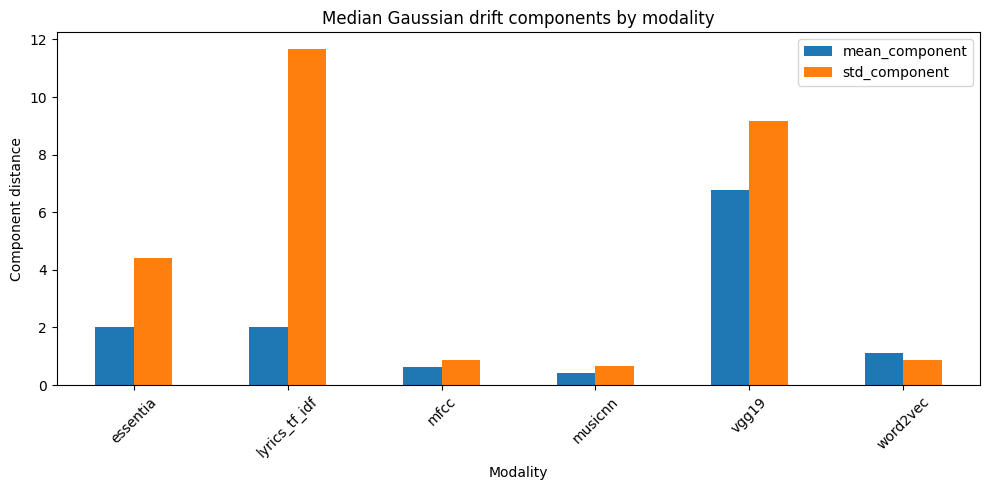

In [12]:
component_plot = (
    dataset_combined
    .groupby("modality")[["mean_component", "std_component"]]
    .median()
    .reset_index()
)

component_plot.plot(
    x="modality",
    y=["mean_component", "std_component"],
    kind="bar",
    figsize=(10, 5),
    rot=45
)

plt.title("Median Gaussian drift components by modality")
plt.xlabel("Modality")
plt.ylabel("Component distance")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rq1_gaussian_drift_components_by_modality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "rq1_gaussian_drift_components_by_modality.pdf",
    bbox_inches="tight"
)

plt.show()


- **Lyrics TF-IDF:** genres change mainly by becoming more or less lyrically diverse, not only by shifting their average lyrical profile
- **Essentia:** acoustic characteristics within genres vary more strongly over time, while the average profile moves less
- **MFCC:** changes are driven more by changing timbral diversity than by a large shift of the average timbre
- **MusicNN:** genre representations stay relatively stable on average, but their internal variation still changes
- **VGG19:** both the typical visual style and the diversity of cover-art representations change substantially
- **Word2Vec:** the average semantic position shifts more than the internal semantic diversity changes
- **Overall:** most modalities evolve mainly through changes in how diverse the tracks inside a genre are
- **Exception:** Word2Vec evolves more through movement of the average semantic representation

# temporal comparison


In [13]:
temporal_summary = (
    dataset_combined
    .groupby(["modality", "window_start"])
    .agg(
        n_valid_transitions=("genre", "count"),
        mean_cosine_drift=("cosine_distance", "mean"),
        median_cosine_drift=("cosine_distance", "median"),
        mean_w2_drift=("w2_distance", "mean"),
        median_w2_drift=("w2_distance", "median")
    )
    .reset_index()
)

temporal_summary.to_csv(
    TABLE_DIR / "rq1_centroid_gaussian_temporal_summary.csv",
    index=False
)

temporal_summary.head()


,modality,window_start,n_valid_transitions,mean_cosine_drift,median_cosine_drift,mean_w2_drift,median_w2_drift
0,essentia,1951,1,0.244992,0.244992,4.711294,4.711294
1,essentia,1952,1,0.119405,0.119405,4.573006,4.573006
2,essentia,1953,1,0.056648,0.056648,2.911234,2.911234
3,essentia,1954,1,0.029422,0.029422,2.796681,2.796681
4,essentia,1955,1,0.038918,0.038918,2.593547,2.593547


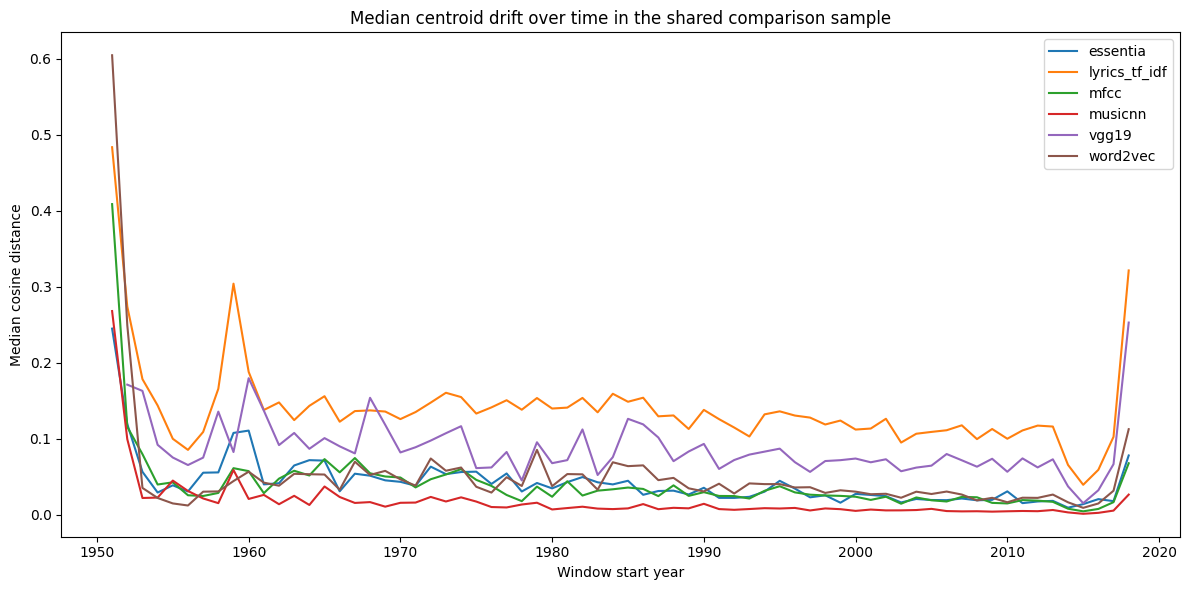

In [14]:
plt.figure(figsize=(12, 6))

for modality, modality_data in temporal_summary.groupby("modality"):
    plt.plot(
        modality_data["window_start"],
        modality_data["median_cosine_drift"],
        label=modality
    )

plt.xlabel("Window start year")
plt.ylabel("Median cosine distance")
plt.title("Median centroid drift over time in the shared comparison sample")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rq1_comparison_median_centroid_drift_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "rq1_comparison_median_centroid_drift_over_time.pdf",
    bbox_inches="tight"
)

plt.show()


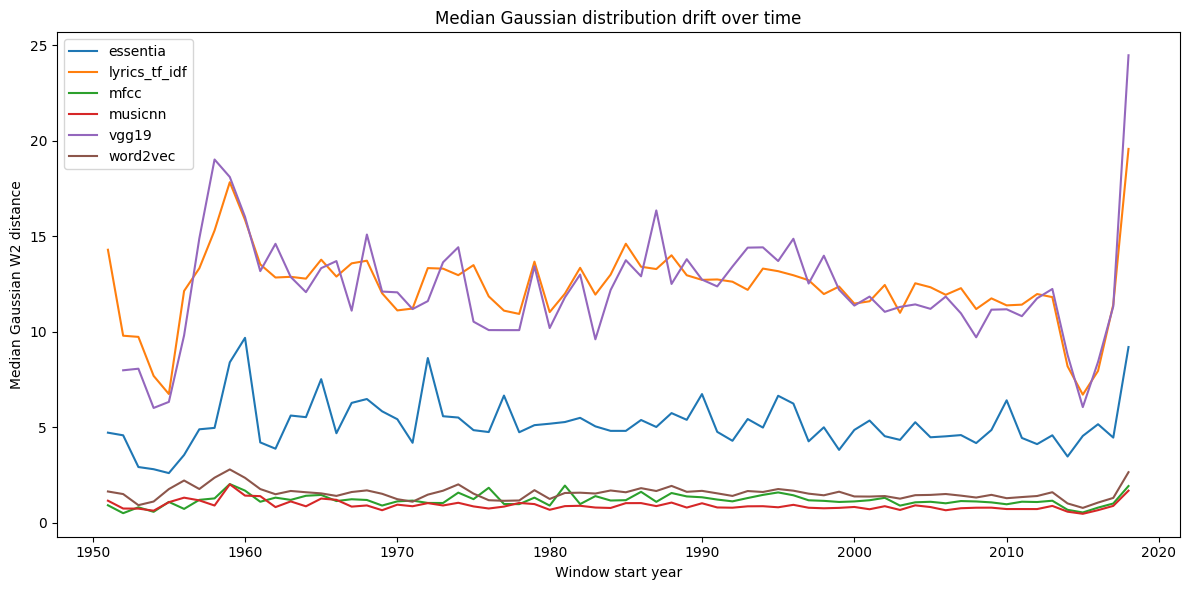

In [15]:
plt.figure(figsize=(12, 6))

for modality, modality_data in temporal_summary.groupby("modality"):
    plt.plot(
        modality_data["window_start"],
        modality_data["median_w2_drift"],
        label=modality
    )

plt.xlabel("Window start year")
plt.ylabel("Median Gaussian W2 distance")
plt.title("Median Gaussian distribution drift over time")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rq1_comparison_median_gaussian_drift_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "rq1_comparison_median_gaussian_drift_over_time.pdf",
    bbox_inches="tight"
)

plt.show()


# agreement and disagreement cases


- **high_both:** strong centroid drift and strong Gaussian drift
- **low_both:** low centroid drift and low Gaussian drift
- **high_cosine_low_w2:** centroid changes strongly, but the full distribution changes little
- **high_w2_low_cosine:** full distribution changes strongly, but centroid direction changes little
- **other:** no clear extreme agreement or disagreement

- **high_both:** average position changes strongly and internal distribution changes strongly
  - Example: a genre shifts toward new semantic themes and also becomes more heterogeneous

- **low_both:** average position stays stable and internal distribution also stays stable
  - Example: a genre keeps a similar average profile and similar diversity

- **high_cosine_low_w2:** centroid direction changes strongly, but the overall distribution changes little
  - Example: the average profile rotates in feature space, while the distribution remains relatively compact and structurally similar

- **high_w2_low_cosine:** centroid direction changes little, but the distribution changes strongly
  - Example: the average profile stays similar, while within-genre variability changes a lot

- **other:** no extreme pattern
  - Example: moderate centroid movement and moderate distributional change

In [16]:
dataset_combined["cosine_percentile"] = (
    dataset_combined
    .groupby("modality")["cosine_distance"]
    .rank(pct=True)
)

dataset_combined["w2_percentile"] = (
    dataset_combined
    .groupby("modality")["w2_distance"]
    .rank(pct=True)
)

dataset_combined["rank_difference"] = (
    dataset_combined["w2_percentile"]
    - dataset_combined["cosine_percentile"]
)

dataset_combined["absolute_rank_difference"] = (
    dataset_combined["rank_difference"].abs()
)

dataset_combined["comparison_group"] = np.select(
    [
        (
            (dataset_combined["cosine_percentile"] >= 0.90)
            & (dataset_combined["w2_percentile"] >= 0.90)
        ),
        (
            (dataset_combined["cosine_percentile"] <= 0.10)
            & (dataset_combined["w2_percentile"] <= 0.10)
        ),
        (
            (dataset_combined["cosine_percentile"] <= 0.25)
            & (dataset_combined["w2_percentile"] >= 0.75)
        ),
        (
            (dataset_combined["cosine_percentile"] >= 0.75)
            & (dataset_combined["w2_percentile"] <= 0.25)
        )
    ],
    [
        "high_both",
        "low_both",
        "high_w2_low_cosine",
        "high_cosine_low_w2"
    ],
    default="other"
)

comparison_group_counts = (
    dataset_combined
    .groupby(["modality", "comparison_group"])
    .size()
    .reset_index(name="n_transitions")
)

comparison_group_counts.to_csv(
    TABLE_DIR / "rq1_centroid_gaussian_agreement_counts.csv",
    index=False
)

comparison_group_counts


,modality,comparison_group,n_transitions
0,essentia,high_both,86
1,essentia,high_cosine_low_w2,39
2,essentia,high_w2_low_cosine,49
3,essentia,low_both,88
4,essentia,other,2253
5,lyrics_tf_idf,high_both,177
6,lyrics_tf_idf,high_cosine_low_w2,6
7,lyrics_tf_idf,high_w2_low_cosine,2
8,lyrics_tf_idf,low_both,144
9,lyrics_tf_idf,other,2186


# strongest agreement cases


In [25]:
example_columns = [
    "modality",
    "genre",
    "window_start",
    "next_window_start",
    "cosine_distance",
    "w2_distance",
    "mean_component",
    "std_component",
    "cosine_percentile",
    "w2_percentile",
    "comparison_group"
]

high_both_examples = (
    dataset_combined[
        dataset_combined["comparison_group"] == "high_both"
    ]
    .sort_values(
        ["cosine_percentile", "w2_percentile"],
        ascending=False
    )
    [example_columns]
    .groupby("modality", group_keys=False)
    .head(5)
)

high_w2_low_cosine_examples = (
    dataset_combined[
        dataset_combined["comparison_group"] == "high_w2_low_cosine"
    ]
    .sort_values(
        "rank_difference",
        ascending=False
    )
    [example_columns]
    .groupby("modality", group_keys=False)
    .head(5)
)

high_cosine_low_w2_examples = (
    dataset_combined[
        dataset_combined["comparison_group"] == "high_cosine_low_w2"
    ]
    .sort_values(
        "rank_difference",
        ascending=True
    )
    [example_columns]
    .groupby("modality", group_keys=False)
    .head(5)
)

print("HIGH BOTH")
display(high_both_examples)


HIGH BOTH


,modality,genre,window_start,next_window_start,cosine_distance,w2_distance,mean_component,std_component,cosine_percentile,w2_percentile,comparison_group
7723,mfcc,blues,2011,2012,0.544532,15.045848,2.811359,14.780859,1.000000,1.000000,high_both
785,essentia,folk rock,2015,2016,0.878577,77.227728,21.320094,74.226516,1.000000,0.999602,high_both
4950,lyrics_tf_idf,synthpop,2018,2019,0.518678,24.122766,4.561681,23.687527,1.000000,0.995229,high_both
11991,musicnn,progressive rock,1995,1996,0.350224,1.963563,1.164686,1.580849,1.000000,0.913718,high_both
4533,lyrics_tf_idf,punk,2018,2019,0.516366,27.031308,5.759516,26.410596,0.999602,0.999205,high_both
697,essentia,experimental,1995,1996,0.616089,50.325226,9.371245,49.445002,0.999602,0.998012,high_both
11587,musicnn,neofolk,2013,2014,0.311871,4.540711,3.225950,3.195512,0.999602,0.996421,high_both
9468,mfcc,progressive rock,1987,1988,0.519833,6.899628,2.995383,6.215509,0.999602,0.994831,high_both
6184,word2vec,industrial,2003,2004,0.591529,4.157074,3.565284,2.137760,0.999602,0.988469,high_both
14368,vgg19,progressive rock,1987,1988,0.657487,37.249668,24.608684,27.963377,0.999572,0.994867,high_both


- **Overall:** these are the strongest temporal changes under both centroid and Gaussian representations
- **Spread-dominated cases:** many examples, such as blues, folk rock, synthpop, reggae, and hardcore
- **Mean-dominated or balanced cases:** more visible for Word2Vec and VGG19 examples
- **Repeated genres:** progressive rock and synthpop appear across several modalities, suggesting robust multimodal change
- **Late-period concentration:** many extreme cases occur around 2018–2019
- **Interpretation:** both the average genre position and the internal track distribution changed strongly

In [26]:
print("HIGH W2, LOW COSINE")
display(high_w2_low_cosine_examples)


HIGH W2, LOW COSINE


,modality,genre,window_start,next_window_start,cosine_distance,w2_distance,mean_component,std_component,cosine_percentile,w2_percentile,comparison_group
5384,word2vec,contemporary classical,2013,2014,0.001017,4.548268,0.958744,4.446071,0.039761,0.995626,high_w2_low_cosine
5291,word2vec,chiptune,2013,2014,0.002750,4.313913,1.390825,4.083559,0.081113,0.992048,high_w2_low_cosine
5376,word2vec,classical,2013,2014,0.003213,3.773120,1.373324,3.514316,0.090258,0.979324,high_w2_low_cosine
7405,word2vec,soundtrack,2018,2019,0.004301,5.732283,4.232520,3.865856,0.114115,0.999205,high_w2_low_cosine
7481,word2vec,techno,2014,2015,0.002464,3.191089,1.434253,2.850608,0.073161,0.955070,high_w2_low_cosine
112,essentia,black metal,1990,1991,0.005754,11.367506,2.061143,11.179082,0.081113,0.927634,high_w2_low_cosine
623,essentia,electronic,2007,2008,0.007749,15.441442,0.819440,15.419684,0.129622,0.966203,high_w2_low_cosine
114,essentia,black metal,1992,1993,0.004375,9.382412,1.789204,9.210234,0.050895,0.886282,high_w2_low_cosine
1042,essentia,hip hop,2015,2016,0.006001,10.799980,0.948510,10.758248,0.087873,0.920875,high_w2_low_cosine
1681,essentia,pop,2009,2010,0.005463,9.564473,0.618380,9.544462,0.075149,0.891054,high_w2_low_cosine


- **Overall:** centroid direction stays mostly stable, but the full genre distribution changes strongly
- **Main driver:** usually large changes in within-genre spread rather than mean movement
- **Word2Vec examples:** semantic average remains similar, while internal semantic diversity changes strongly
- **Essentia examples:** average acoustic profile stays similar, but acoustic variability changes
- **MusicNN / MFCC:** stable centroid with noticeable changes in internal feature spread
- **VGG19:** visual average changes little, but cover-art distributions shift substantially
- **Lyrics TF-IDF:** rare cases; lyrical centroid is relatively stable while lyrical variability changes
- **Interpretation:** centroid-only analysis would miss these distributional changes

In [27]:
print("HIGH COSINE, LOW W2")
display(high_cosine_low_w2_examples)

HIGH COSINE, LOW W2


,modality,genre,window_start,next_window_start,cosine_distance,w2_distance,mean_component,std_component,cosine_percentile,w2_percentile,comparison_group
2109,essentia,rock,1976,1977,0.230845,2.781163,1.049501,2.575542,0.984493,0.100596,high_cosine_low_w2
9658,mfcc,rock,1980,1981,0.147462,0.525375,0.381942,0.360749,0.951491,0.109742,high_cosine_low_w2
2114,essentia,rock,1981,1982,0.098269,2.562521,0.963889,2.374327,0.906958,0.072366,high_cosine_low_w2
8762,mfcc,jazz,1952,1953,0.115829,0.493164,0.372594,0.323087,0.924851,0.091849,high_cosine_low_w2
9655,mfcc,rock,1977,1978,0.150876,0.552138,0.346453,0.429916,0.953479,0.122863,high_cosine_low_w2
2112,essentia,rock,1979,1980,0.135478,2.948089,0.970287,2.783842,0.950696,0.127237,high_cosine_low_w2
291,essentia,classic rock,1975,1976,0.111539,2.849307,1.319879,2.525167,0.924453,0.111332,high_cosine_low_w2
2119,essentia,rock,1986,1987,0.107616,2.814641,0.988414,2.635383,0.918489,0.107753,high_cosine_low_w2
12624,vgg19,alternative rock,2012,2013,0.195695,6.152058,4.602133,4.082669,0.907186,0.122327,high_cosine_low_w2
7134,word2vec,rock,1971,1972,0.101786,0.663923,0.506951,0.428713,0.873956,0.099006,high_cosine_low_w2


- **Overall:** centroid direction changes strongly, but the full Gaussian distribution changes only a little
- **Rock dominates:** repeated across Essentia, MFCC, Word2Vec, MusicNN, and Lyrics TF-IDF
- **Interpretation:** the average genre profile rotates in feature space without a large overall shift in mean and spread
- **Essentia / MFCC:** directional acoustic change, but limited distributional restructuring
- **Word2Vec:** semantic centroid direction changes while the semantic distribution remains relatively stable
- **VGG19:** visual profile direction changes, but total distributional change stays low relative to other VGG19 transitions
- **Lyrics TF-IDF:** centroid direction changes strongly, although this is still a low-W2 case only relative to other TF-IDF transitions
- **Important:** “low W2” is percentile-based within each modality, not necessarily numerically small across modalities